In [3]:
# Install the libraries we need
!pip install scikit-learn tensorflow -q
print()

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)
print()

In [6]:
N = 1000  # Number of samples
WINDOW = 50 # Length of each time series

X = []
y = []

for _ in range(N):
    w = np.zeros(WINDOW)
    # Humans cause 2-5 bursts of movement
    for _ in range(np.random.randint(2, 6)):
        start = np.random.randint(0, WINDOW - 8)
        length = np.random.randint(4, 10)
        w[start:start+length] = np.random.uniform(0.8, 1.0)
    w += np.random.normal(0, 0.04, WINDOW)  # add noise
    X.append(np.clip(w, 0, 1))
    y.append(1)

# Create 1000 false alarm examples
for _ in range(N):
    w = np.zeros(WINDOW)
    kind = np.random.choice(['spike', 'noise', 'animal'])
    if kind == 'spike':
        p = np.random.randint(5, WINDOW - 5)
        w[p:p+2] = np.random.uniform(0.7, 1.0, 2)
    elif kind == 'noise':
        w = np.random.uniform(0, 0.25, WINDOW)
    else:
        p = np.random.randint(0, WINDOW - 4)
        w[p:p+3] = np.random.uniform(0.5, 0.9, 3)
    w += np.random.normal(0, 0.03, WINDOW)
    X.append(np.clip(w, 0, 1))
    y.append(0)

X = np.array(X, dtype=np.float32)
y = np.array(y)

# Split into train / val / test
X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.125, stratify=y_tv, random_state=42)

print(f"Total samples: {len(X)}")
print(f"Training: {len(X_train)}  |  Validation: {len(X_val)}  |  Test: {len(X_test)}")
print(f"Human motion samples: {np.sum(y==1)}")
print(f"False alarm samples:  {np.sum(y==0)}")

Total samples: 2000
Training: 1400  |  Validation: 200  |  Test: 400
Human motion samples: 1000
False alarm samples:  1000


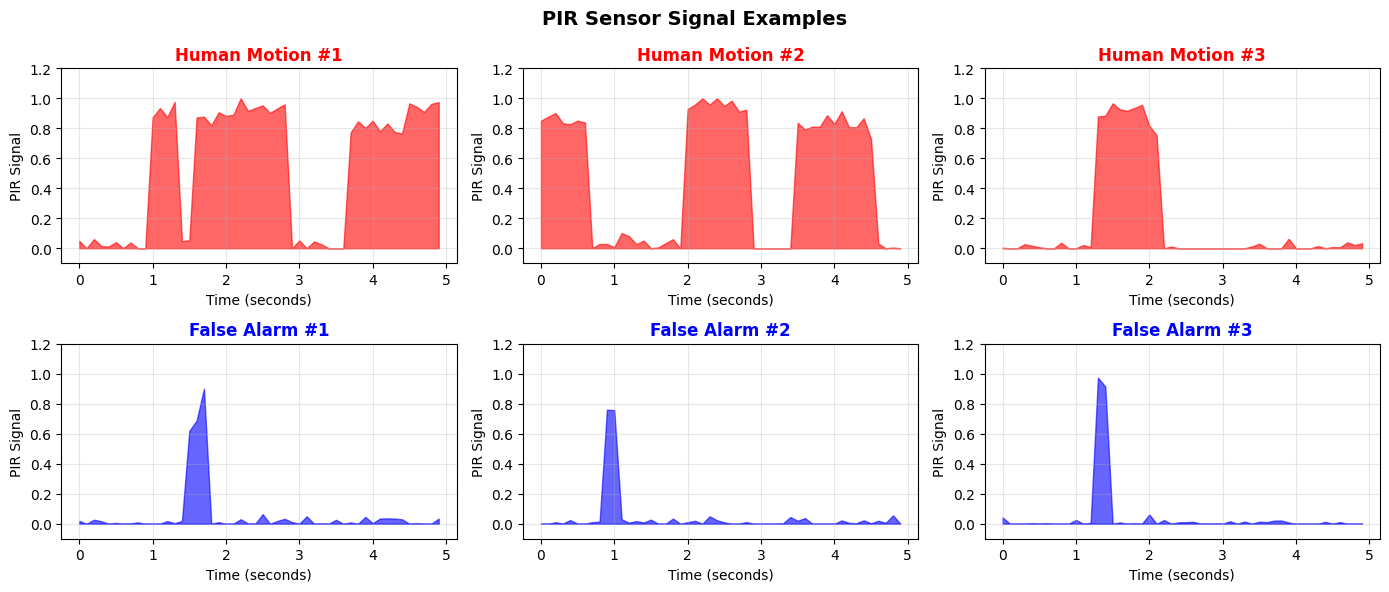

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
fig.suptitle('PIR Sensor Signal Examples', fontsize=14, fontweight='bold')

t = np.arange(WINDOW) * 0.1  # time in seconds


for i, ax in enumerate(axes[0]):
    idx = np.where(y_train == 1)[0][i]
    ax.fill_between(t, X_train[idx], alpha=0.6, color='red')
    ax.set_title(f'Human Motion #{i+1}', color='red', fontweight='bold')
    ax.set_ylim(-0.1, 1.2)
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('PIR Signal')
    ax.grid(alpha=0.3)


for i, ax in enumerate(axes[1]):
    idx = np.where(y_train == 0)[0][i]
    ax.fill_between(t, X_train[idx], alpha=0.6, color='blue')
    ax.set_title(f'False Alarm #{i+1}', color='blue', fontweight='bold')
    ax.set_ylim(-0.1, 1.2)
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('PIR Signal')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pir_samples.png', dpi=150)
plt.show()
print()

In [8]:

def get_features(X):
    out = []
    for w in X:
        out.append([
            np.mean(w),
            np.std(w),
            np.max(w),
            np.sum(w > 0.5),
            np.sum((w[:-1] < 0.5) & (w[1:] >= 0.5)),
            np.sum(np.abs(np.diff(w))),
            np.percentile(w, 75) - np.percentile(w, 25)
        ])
    return np.array(out, dtype=np.float32)

Xf_train = get_features(X_train)
Xf_val   = get_features(X_val)
Xf_test  = get_features(X_test)


sc = StandardScaler()
Xf_train = sc.fit_transform(Xf_train)
Xf_val   = sc.transform(Xf_val)
Xf_test  = sc.transform(Xf_test)


X_train_3d = X_train.reshape(-1, WINDOW, 1)
X_val_3d   = X_val.reshape(-1, WINDOW, 1)
X_test_3d  = X_test.reshape(-1, WINDOW, 1)

print("Features shape:", Xf_train.shape)
print("3D shape for deep learning:", X_train_3d.shape)
print()

Features shape: (1400, 7)
3D shape for deep learning: (1400, 50, 1)



In [9]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

t0 = time.time()
rf.fit(Xf_train, y_train)
rf_train_time = time.time() - t0

rf_pred = rf.predict(Xf_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_f1  = f1_score(y_test, rf_pred, average='weighted')

print("=" * 45)
print("MODEL 1: Random Forest")
print("=" * 45)
print(f"Accuracy:       {rf_acc * 100:.2f}%")
print(f"F1 Score:       {rf_f1:.4f}")
print(f"Training time:  {rf_train_time:.2f} seconds")
print()
print(classification_report(y_test, rf_pred, target_names=['false_alarm', 'human_motion']))

MODEL 1: Random Forest
Accuracy:       100.00%
F1 Score:       1.0000
Training time:  0.36 seconds

              precision    recall  f1-score   support

 false_alarm       1.00      1.00      1.00       200
human_motion       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [10]:
t0 = time.time()
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(Xf_train, y_train)
svm_train_time = time.time() - t0

svm_pred = svm.predict(Xf_test)

svm_acc = accuracy_score(y_test, svm_pred)
svm_f1  = f1_score(y_test, svm_pred, average='weighted')

print("=" * 45)
print("MODEL 2: SVM (RBF kernel)")
print("=" * 45)
print(f"Accuracy:       {svm_acc * 100:.2f}%")
print(f"F1 Score:       {svm_f1:.4f}")
print(f"Training time:  {svm_train_time:.2f} seconds")
print()
print(classification_report(y_test, svm_pred, target_names=['false_alarm', 'human_motion']))

MODEL 2: SVM (RBF kernel)
Accuracy:       100.00%
F1 Score:       1.0000
Training time:  0.01 seconds

              precision    recall  f1-score   support

 false_alarm       1.00      1.00      1.00       200
human_motion       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [11]:
lstm = keras.Sequential([
    keras.layers.Input(shape=(WINDOW, 1)),
    keras.layers.LSTM(32, return_sequences=True),
    keras.layers.Dropout(0.2),
    keras.layers.LSTM(16),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(2, activation='softmax')
], name='LSTM')

lstm.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

# Stop early if model stops improving
cb = [keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=8,
    restore_best_weights=True, verbose=0)]

t0 = time.time()
lstm.fit(X_train_3d, y_train,
         validation_data=(X_val_3d, y_val),
         epochs=50, batch_size=32,
         callbacks=cb, verbose=1)
lstm_train_time = time.time() - t0

lstm_pred = np.argmax(lstm.predict(X_test_3d, verbose=0), axis=1)

lstm_acc = accuracy_score(y_test, lstm_pred)
lstm_f1  = f1_score(y_test, lstm_pred, average='weighted')

print("=" * 45)
print("MODEL 3: LSTM")
print("=" * 45)
print(f"Accuracy:       {lstm_acc * 100:.2f}%")
print(f"F1 Score:       {lstm_f1:.4f}")
print(f"Training time:  {lstm_train_time:.2f} seconds")
print()
print(classification_report(y_test, lstm_pred, target_names=['false_alarm', 'human_motion']))

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 117ms/step - accuracy: 0.8850 - loss: 0.4600 - val_accuracy: 0.9900 - val_loss: 0.1499
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.9950 - loss: 0.0623 - val_accuracy: 1.0000 - val_loss: 0.0137
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9943 - loss: 0.0226 - val_accuracy: 1.0000 - val_loss: 0.0075
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 1.0000 - loss: 0.0074 - val_accuracy: 1.0000 - val_loss: 0.0030
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 8.1197e-04
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 1.0000 - loss: 7.1878e-04 - val_accuracy: 

In [12]:
cnn = keras.Sequential([
    keras.layers.Input(shape=(WINDOW, 1)),
    keras.layers.Conv1D(16, kernel_size=5, activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling1D(2),
    keras.layers.Dropout(0.2),
    keras.layers.Conv1D(32, kernel_size=3, activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling1D(2),
    keras.layers.Dropout(0.2),
    keras.layers.Flatten(),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(2, activation='softmax')
], name='CNN_1D')

cnn.compile(optimizer=keras.optimizers.Adam(0.001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cb2 = [keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=10,
    restore_best_weights=True, verbose=0)]

t0 = time.time()
history = cnn.fit(X_train_3d, y_train,
                  validation_data=(X_val_3d, y_val),
                  epochs=60, batch_size=32,
                  callbacks=cb2, verbose=1)
cnn_train_time = time.time() - t0

cnn_pred = np.argmax(cnn.predict(X_test_3d, verbose=0), axis=1)

cnn_acc = accuracy_score(y_test, cnn_pred)
cnn_f1  = f1_score(y_test, cnn_pred, average='weighted')

print("=" * 45)
print("MODEL 4: 1D CNN (selected for ESP32)")
print("=" * 45)
print(f"Accuracy:       {cnn_acc * 100:.2f}%")
print(f"F1 Score:       {cnn_f1:.4f}")
print(f"Training time:  {cnn_train_time:.2f} seconds")
print()
print(classification_report(y_test, cnn_pred, target_names=['false_alarm', 'human_motion']))

Epoch 1/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9171 - loss: 0.2104 - val_accuracy: 0.8900 - val_loss: 0.4415
Epoch 2/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9893 - loss: 0.0373 - val_accuracy: 0.6650 - val_loss: 0.4630
Epoch 3/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9907 - loss: 0.0265 - val_accuracy: 0.6600 - val_loss: 0.5110
Epoch 4/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9971 - loss: 0.0137 - val_accuracy: 0.6900 - val_loss: 0.5057
Epoch 5/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9957 - loss: 0.0133 - val_accuracy: 0.8150 - val_loss: 0.3539
Epoch 6/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9971 - loss: 0.0080 - val_accuracy: 0.8750 - val_loss: 0.2548
Epoch 7/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9964 - loss: 0.0065 - val_accuracy: 0.9300 - val_loss: 0.1326
Epoch 8/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9993 - loss: 0.0035 - val_accuracy: 0.9850 - val_

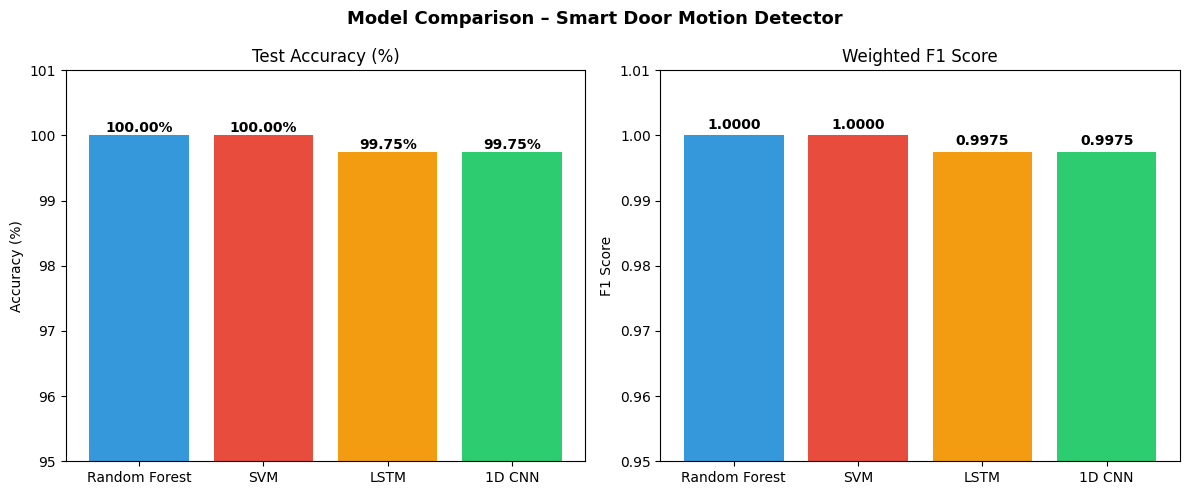

In [13]:
models = ['Random Forest', 'SVM', 'LSTM', '1D CNN']
accs   = [rf_acc, svm_acc, lstm_acc, cnn_acc]
f1s    = [rf_f1,  svm_f1,  lstm_f1,  cnn_f1]
colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Comparison – Smart Door Motion Detector', fontweight='bold', fontsize=13)


bars = ax1.bar(models, [a*100 for a in accs], color=colors)
ax1.set_title('Test Accuracy (%)')
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(95, 101)
for bar, val in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val*100:.2f}%', ha='center', fontweight='bold')


bars2 = ax2.bar(models, f1s, color=colors)
ax2.set_title('Weighted F1 Score')
ax2.set_ylabel('F1 Score')
ax2.set_ylim(0.95, 1.01)
for bar, val in zip(bars2, f1s):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print()

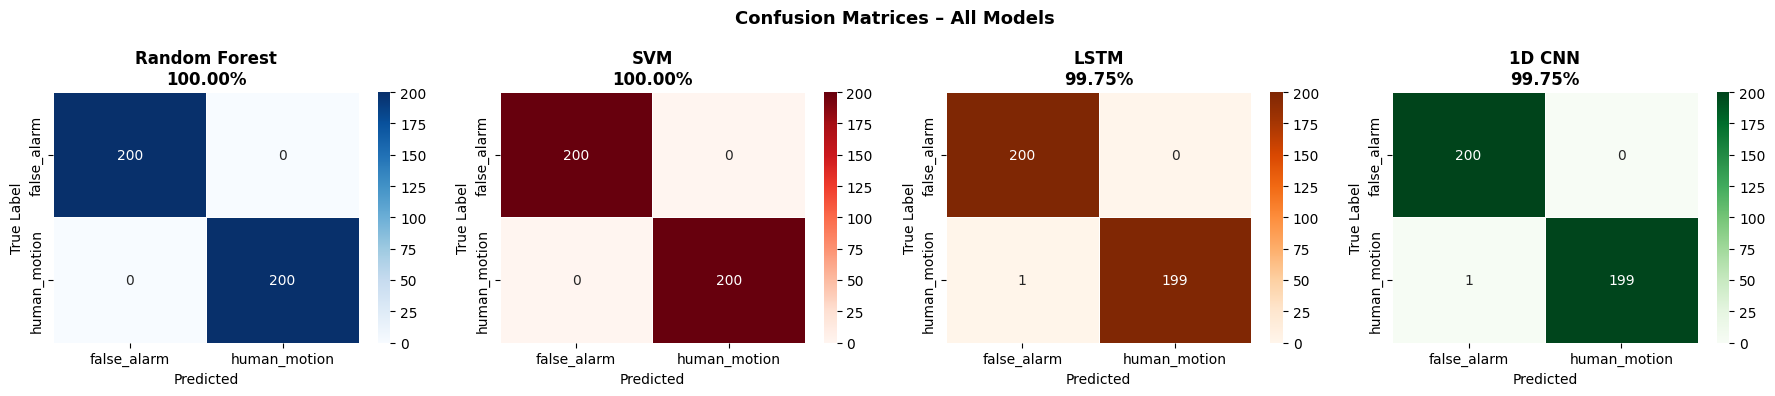

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Confusion Matrices – All Models', fontweight='bold', fontsize=13)

all_preds = [rf_pred, svm_pred, lstm_pred, cnn_pred]
all_names = ['Random Forest', 'SVM', 'LSTM', '1D CNN']
all_cmaps = ['Blues', 'Reds', 'Oranges', 'Greens']
labels    = ['false_alarm', 'human_motion']

for ax, pred, name, cmap in zip(axes, all_preds, all_names, all_cmaps):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels,
                ax=ax, linewidths=0.5)
    ax.set_title(f'{name}\n{accuracy_score(y_test, pred)*100:.2f}%', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print()

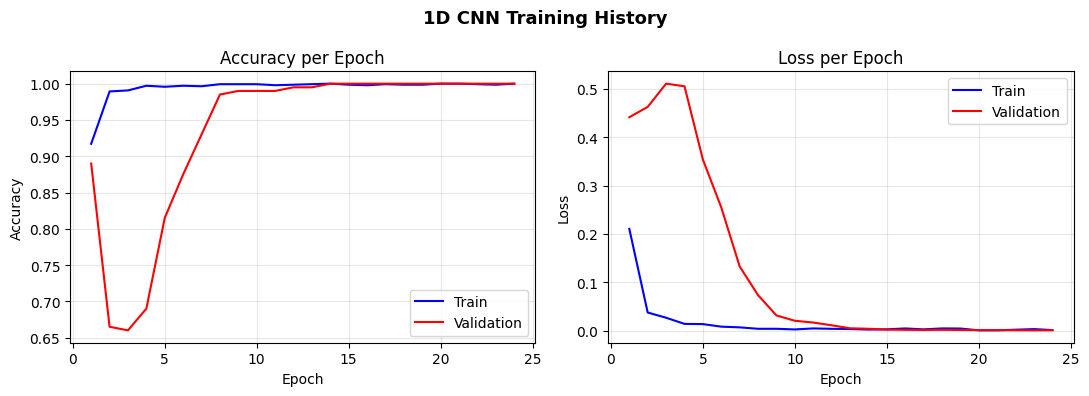

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('1D CNN Training History', fontweight='bold', fontsize=13)

ep = range(1, len(history.history['accuracy']) + 1)

ax1.plot(ep, history.history['accuracy'],     label='Train', color='blue')
ax1.plot(ep, history.history['val_accuracy'], label='Validation', color='red')
ax1.set_title('Accuracy per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(ep, history.history['loss'],     label='Train', color='blue')
ax2.plot(ep, history.history['val_loss'], label='Validation', color='red')
ax2.set_title('Loss per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_training.png', dpi=150)
plt.show()
print()

In [16]:
def rep_data():
    for x in X_train_3d[:200]:
        yield [x.reshape(1, WINDOW, 1).astype(np.float32)]

conv = tf.lite.TFLiteConverter.from_keras_model(cnn)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.representative_dataset = rep_data
conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv.inference_input_type  = tf.float32
conv.inference_output_type = tf.float32

tflite_bytes = conv.convert()

print(f'TFLite model size: {len(tflite_bytes)/1024:.1f} KB')
print()

Saved artifact at '/tmp/tmp4qrrq9xe'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 1), dtype=tf.float32, name='keras_tensor_6')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  134256831517840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134256831527248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134256831514576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134256831528400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134256831525904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134256831522064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134256795617424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134256831527056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134256831527824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134256831520144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134256831528784: T

In [17]:
n = len(tflite_bytes)
rows = []
for i in range(0, n, 16):
    chunk = tflite_bytes[i:i+16]
    rows.append('  ' + ', '.join(f'0x{b:02x}' for b in chunk) + ',')

header = f"""// model_data.h - Auto-generated
// 1D CNN TFLite INT8 | {n} bytes ({n/1024:.1f} KB)
// Input:  float[50]  (5 second PIR window)
// Output: float[2]   (false_alarm prob, human_motion prob)

#ifndef MODEL_DATA_H
#define MODEL_DATA_H

const unsigned char g_model_data[] = {{
{chr(10).join(rows)}
}};
const int g_model_data_len = {n};

#endif
"""

with open('model_data.h', 'w') as f:
    f.write(header)

print(f'model_data.h created — {n} bytes')


from google.colab import files
for fname in ['model_data.h', 'pir_samples.png',
              'model_comparison.png', 'confusion_matrices.png',
              'cnn_training.png']:
    files.download(fname)
    print(f'Downloading: {fname}')

model_data.h created — 26280 bytes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: model_data.h


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloading: confusion_matrices.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: cnn_training.png
